In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
import numpy as np

db = mysql.connector.connect(host = 'localhost',username = 'root',password = 'surajsingh1080',database = 'ecommerce')
curr=db.cursor()

#List all unique cities where customers are located

In [30]:
query = """ select distinct customer_city from customers """
curr.execute(query)
data = curr.fetchall()
data

[('franca',),
 ('sao bernardo do campo',),
 ('sao paulo',),
 ('mogi das cruzes',),
 ('campinas',),
 ('jaragua do sul',),
 ('timoteo',),
 ('curitiba',),
 ('belo horizonte',),
 ('montes claros',),
 ('rio de janeiro',),
 ('lencois paulista',),
 ('caxias do sul',),
 ('piracicaba',),
 ('guarulhos',),
 ('pacaja',),
 ('florianopolis',),
 ('aparecida de goiania',),
 ('santo andre',),
 ('goiania',),
 ('cachoeiro de itapemirim',),
 ('sao jose dos campos',),
 ('sao roque',),
 ('camacari',),
 ('resende',),
 ('sumare',),
 ('novo hamburgo',),
 ('sao luis',),
 ('sao jose',),
 ('santa barbara',),
 ('ribeirao preto',),
 ('ituiutaba',),
 ('taquarituba',),
 ('sao jose dos pinhais',),
 ('barrinha',),
 ('parati',),
 ('dourados',),
 ('trindade',),
 ('cascavel',),
 ('fortaleza',),
 ('brasilia',),
 ('pelotas',),
 ('porto alegre',),
 ('salto',),
 ('jundiai',),
 ('cacapava',),
 ('sao vicente',),
 ('uberlandia',),
 ('botelhos',),
 ('sao goncalo',),
 ('araucaria',),
 ('nova iguacu',),
 ('areia branca',),
 ('campo

#Count the order placed in 2017

In [37]:
query = """ select count(order_id) from orders where year(order_purchase_timestamp) = 2017 """
curr.execute(query)
data = curr.fetchall()
data[0][0]

45101

#Find the total sales per category

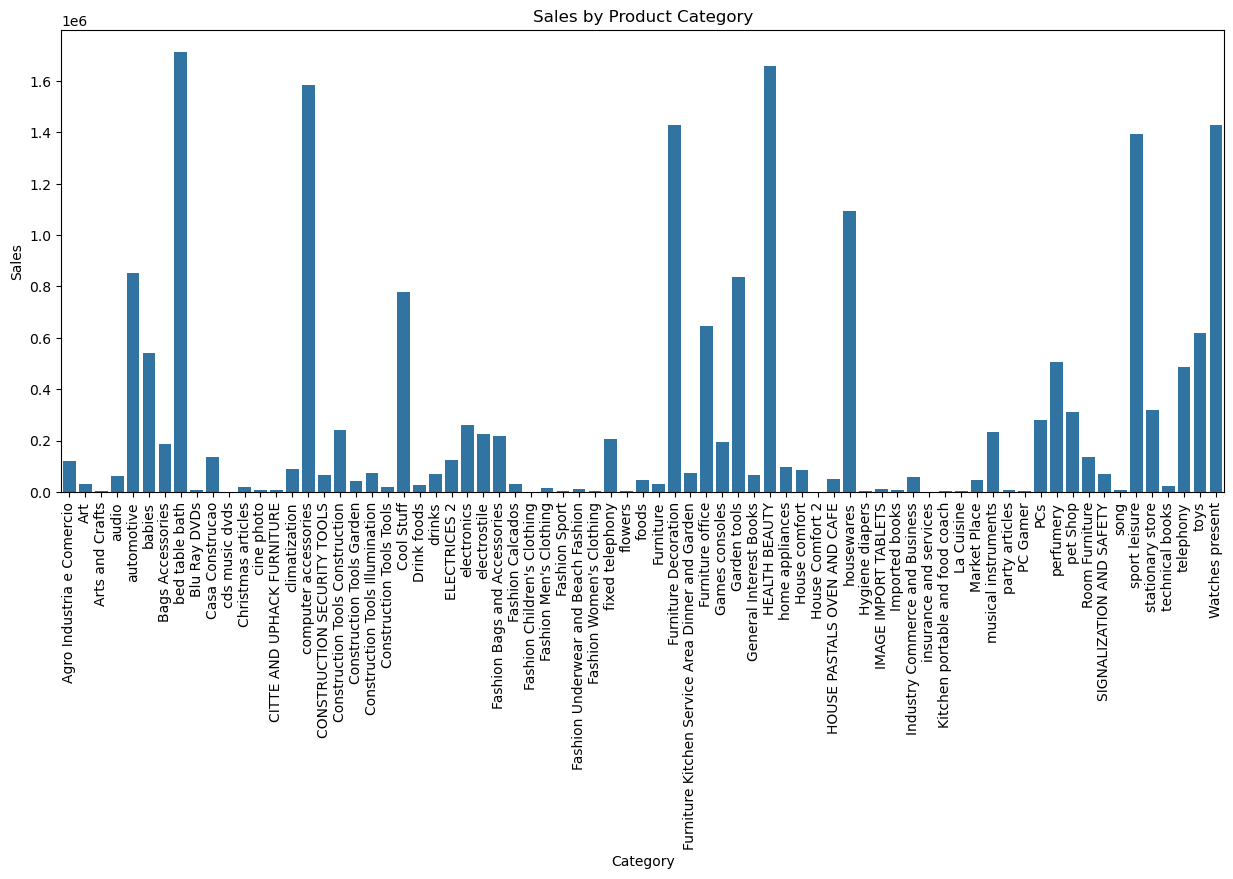

In [44]:
query = """ select products.product_category as category ,round(sum(payments.payment_value),2)
            as sales from products join order_items
            on products.product_id=order_items.product_id join payments
            on payments.order_id=order_items.order_id 
            WHERE products.product_category IS NOT NULL
            group by category 
            order by category; """

curr.execute(query)
data = curr.fetchall()

df = pd.DataFrame(data, columns=['category', 'sales'])

plt.figure(figsize=(15,6))
sns.barplot(data=df, x='category', y='sales')

plt.xticks(rotation=90)
plt.title('Sales by Product Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()

#Calculate percentage of orders that user paid in installments

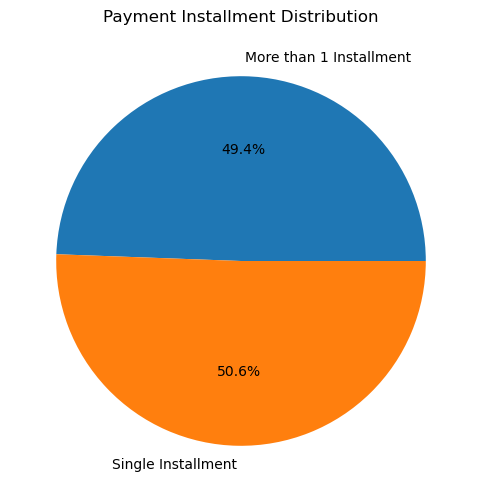

In [53]:
query = """ with instal as (select count(order_id) as cnt 
            from payments where payment_installments > 1),
            total as (select count(order_id) as cnt from payments)
            select (instal.cnt/total.cnt)*100 as percentage
            from instal,total"""

curr.execute(query)
data = curr.fetchall()

installed = data[0][0]
single_payment = 100 - installed

labels = ['More than 1 Installment', 'Single Installment']
sizes = [installed, single_payment]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title('Payment Installment Distribution')
plt.show()

#Count the number of customers from each state

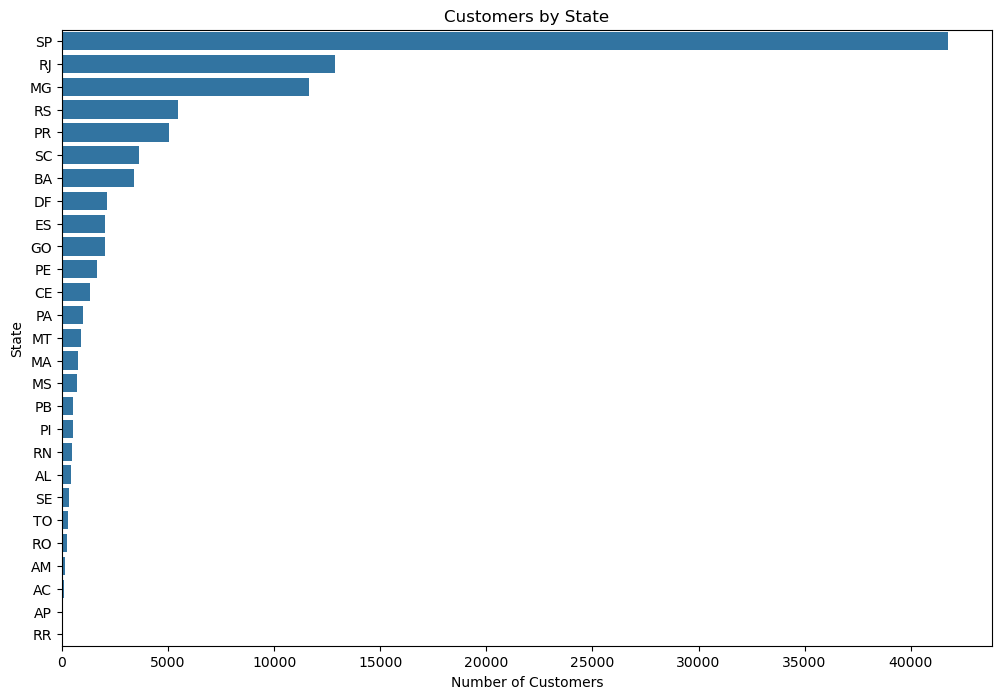

In [64]:
query=""" select customer_state as state,count(customer_id) as customer
            from customers
            group by state; """

curr.execute(query)
data=curr.fetchall()

df = pd.DataFrame(data, columns=['state', 'customer'])

df = df.sort_values('customer', ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(data=df, x='customer', y='state')

plt.title('Customers by State')
plt.xlabel('Number of Customers')
plt.ylabel('State')
plt.show()

#calculate the number of order per month in 2018

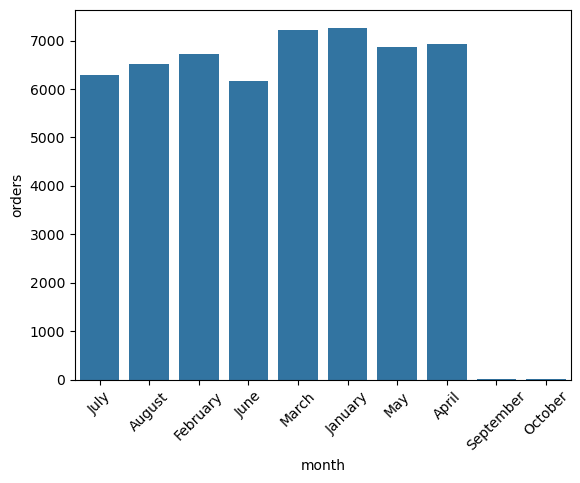

In [87]:
query="""select monthname(order_purchase_timestamp) as month, count(order_id) as orders
        from orders where year(order_purchase_timestamp)=2018
        group by month"""

curr.execute(query)
data = curr.fetchall()

df = pd.DataFrame(data, columns=['month', 'orders'])

sns.barplot(x='month', y='orders', data=df)

plt.xticks(rotation=45)
plt.show()

#Find the average of products per order group by customer city

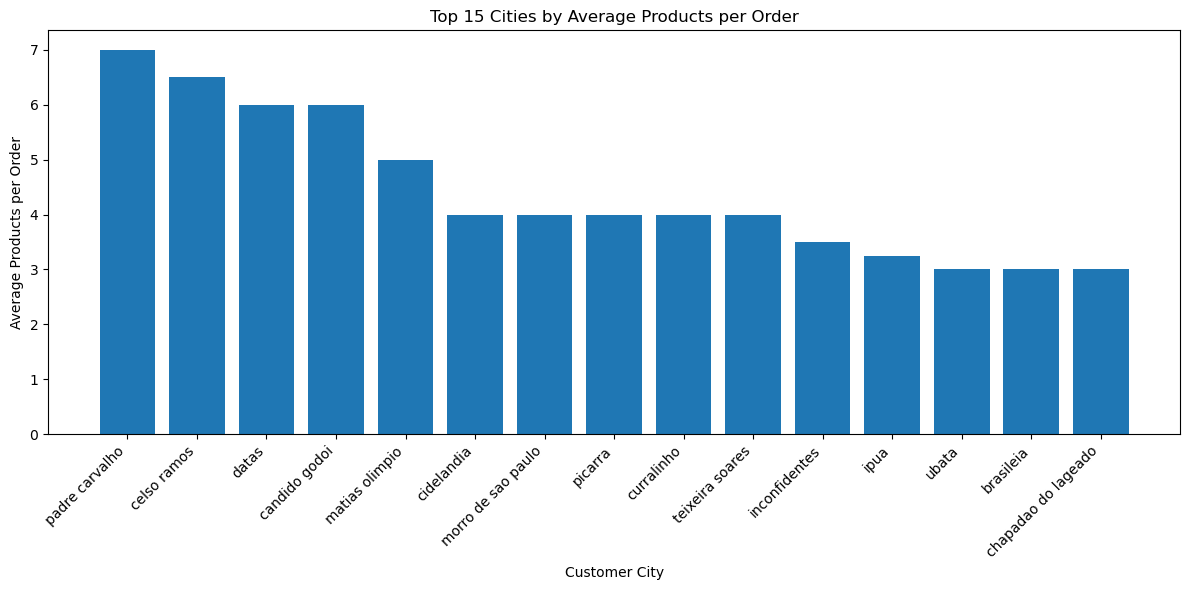

In [13]:
query="""with count_per_order as
        (select orders.order_id,orders.customer_id,count(order_items.order_id) as oc
        from orders join order_items
        on orders.order_id=order_items.order_id
        group by orders.order_id,orders.customer_id)
        select customers.customer_city,round(avg(count_per_order.oc),2) average_orders
        from customers join count_per_order
        on customers.customer_id=count_per_order.customer_id
        group by customers.customer_city"""
curr.execute(query)
data=curr.fetchall()

df=pd.DataFrame(data,columns=["customer_city","average_orders"])
top15 = df.sort_values("average_orders", ascending=False).head(15)

plt.figure(figsize=(12,6))
plt.bar(top15["customer_city"], top15["average_orders"])
plt.xticks(rotation=45, ha='right')
plt.xlabel("Customer City")
plt.ylabel("Average Products per Order")
plt.title("Top 15 Cities by Average Products per Order")
plt.tight_layout()
plt.show()

#Calculate the percentage of total revenue contributed by each product category

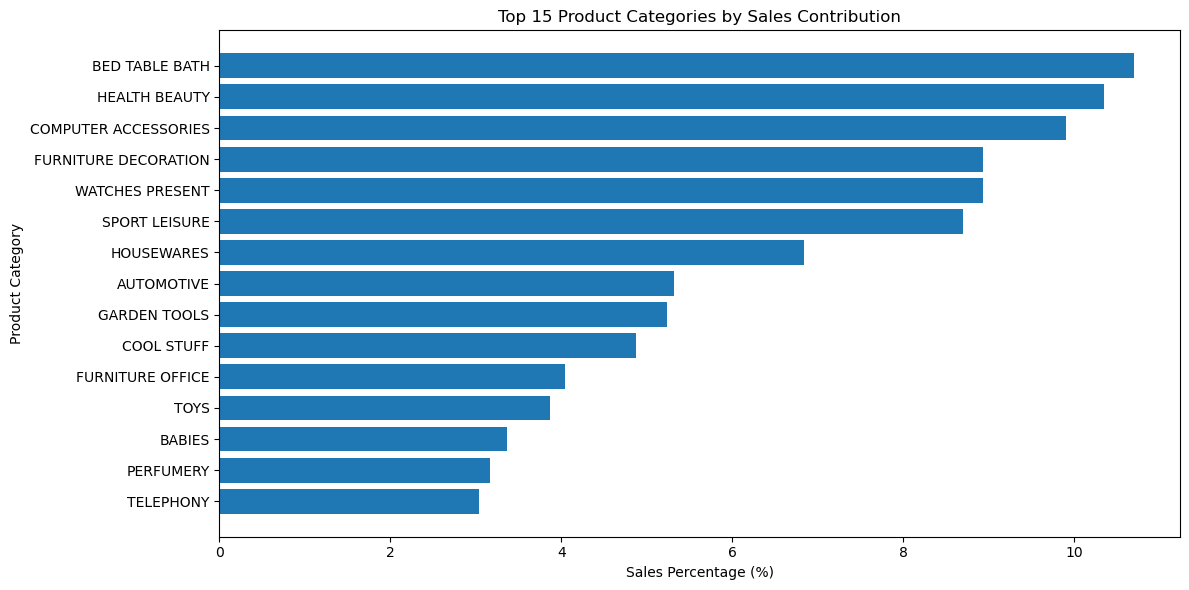

In [18]:
query="""select upper(products.product_category) category,
            round((sum(payments.payment_value)/(select sum(payment_value) from payments))*100,2)
            as sales_percentage
            from products join order_items
            on products.product_id=order_items.product_id
            join payments
            on payments.order_id=order_items.order_id
            group by category order by sales_percentage desc"""
curr.execute(query)
data=curr.fetchall()

df = pd.DataFrame(data, columns=["category", "sales_percentage"])
top15 = df.head(15)

plt.figure(figsize=(12,6))
plt.barh(top15["category"], top15["sales_percentage"])
plt.xlabel("Sales Percentage (%)")
plt.ylabel("Product Category")
plt.title("Top 15 Product Categories by Sales Contribution")
plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()

#Identify the correlation between product price and the number of times a product has been purchased

In [31]:
query="""select products.product_category,count(order_items.product_id),
        round(avg(order_items.price),2)
        from products join order_items
        on products.product_id=order_items.product_id
        group by products.product_category"""
curr.execute(query)
data=curr.fetchall()

df=pd.DataFrame(data,columns=["category","order_count","price"])
arr1=df["order_count"]
arr2=df["price"]
a=np.corrcoef(arr2,arr1);
print("Correlation between product price and the number of times a product has been purchased:",a[0][1])

Correlation between product price and the number of times a product has been purchased: -0.10631514167157562


#calculate the total revenue generated by each seller and rnak them by revenue

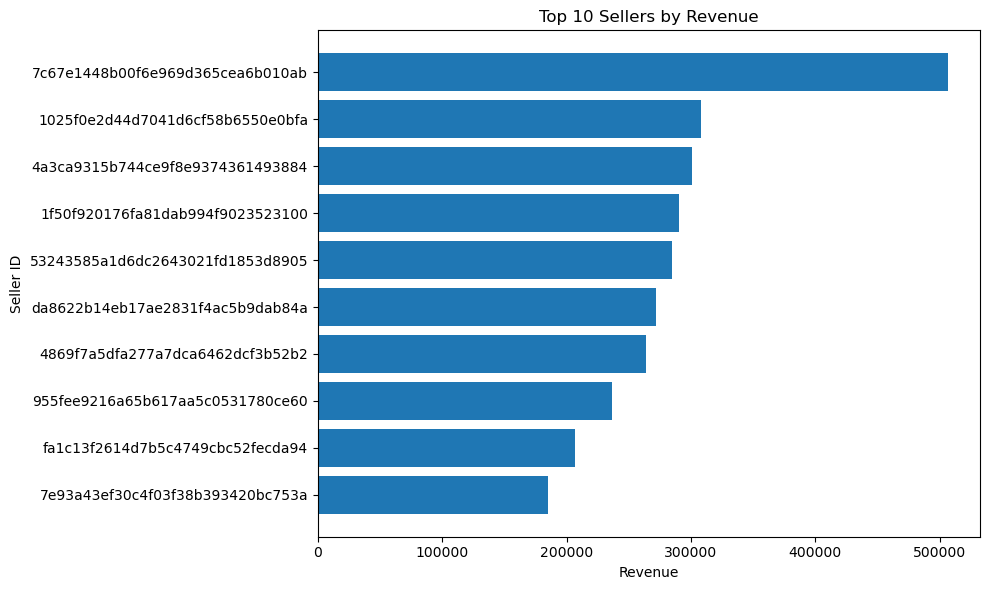

In [36]:
query="""select *,dense_rank() over(order by revenue desc) as ranks
        from (select order_items.seller_id, round(sum(payments.payment_value),2) revenue
        from order_items join payments
        on order_items.order_id=payments.order_id
        group by order_items.seller_id) as a"""
curr.execute(query)
data=curr.fetchall()
df = pd.DataFrame(data, columns=["seller_id", "revenue", "rank"])

top10 = df.sort_values("revenue", ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top10["seller_id"], top10["revenue"])

plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Seller ID")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#calculate the moving average of order values for each customer over their order history

In [39]:
query="""select customer_id,order_purchase_timestamp,payment,
        avg(payment) over(partition by customer_id order by order_purchase_timestamp
        rows between 2 preceding and current row) as mov_avg
        from (select orders.customer_id,orders.order_purchase_timestamp,
        payments.payment_value as payment from payments 
        join orders
        on payments.order_id=orders.order_id)
        as a"""
curr.execute(query)
data=curr.fetchall()
df=pd.DataFrame(data)
df

,0,1,2,3
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.42,195.419998
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,179.35,179.350006
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,107.01,107.010002
...,...,...,...,...
103881,fffecc9f79fd8c764f843e9951b11341,2018-03-29 16:59:26,71.23,27.120001
103882,fffeda5b6d849fbd39689bb92087f431,2018-05-22 13:36:02,63.13,63.130001
103883,ffff42319e9b2d713724ae527742af25,2018-06-13 16:57:05,214.13,214.130005
103884,ffffa3172527f765de70084a7e53aae8,2017-09-02 11:53:32,45.50,45.500000


#calculate the cumulative sales per month for each year

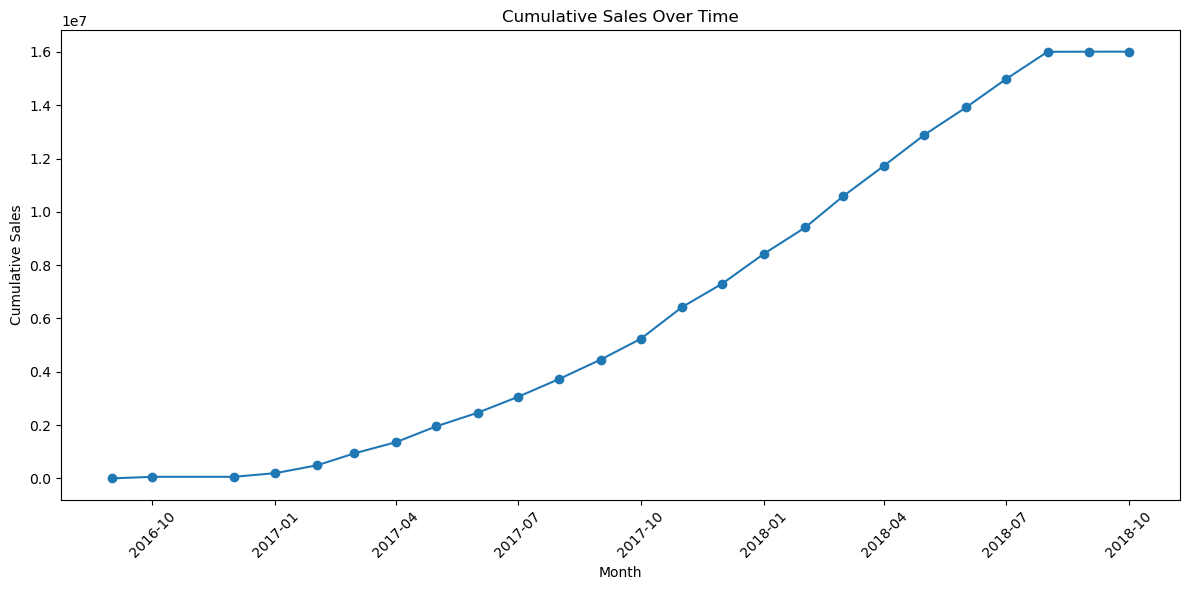

In [44]:
query="""select years,months,payment,sum(payment) 
        over(order by years,months) cumulative_sales
        from(select year(orders.order_purchase_timestamp) as years,
        month(orders.order_purchase_timestamp) as months,
        round(sum(payments.payment_value),2) as payment
        from orders join payments
        on orders.order_id=payments.order_id
        group by years,months order by years,months)
        as a"""
curr.execute(query)
data=curr.fetchall()

df = pd.DataFrame(
    data,
    columns=["year", "month", "payment", "cumulative_sales"]
)

df["period"] = pd.to_datetime(
    df["year"].astype(str) + "-" + df["month"].astype(str)
)

plt.figure(figsize=(12,6))
plt.plot(df["period"], df["cumulative_sales"], marker='o')

plt.title("Cumulative Sales Over Time")
plt.xlabel("Month")
plt.ylabel("Cumulative Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#Calculate the year over year growth rate of total sales

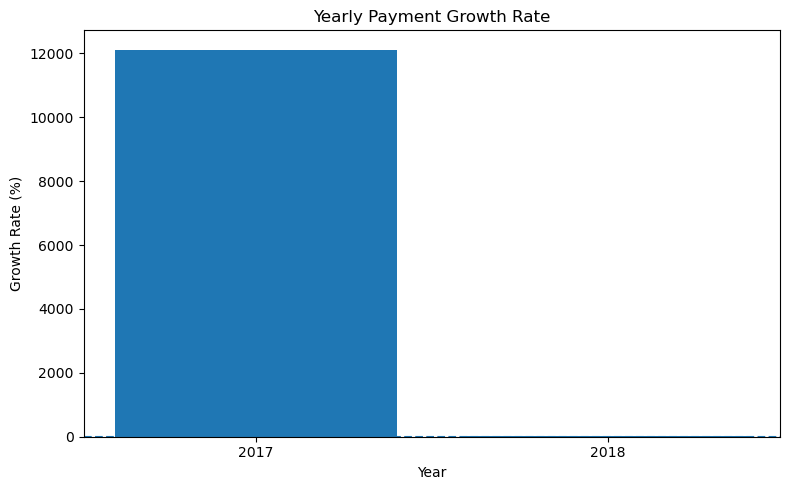

In [18]:
query="""with a as
        (select year(orders.order_purchase_timestamp) as years,
        round(sum(payments.payment_value),2) as payment from orders
        join payments
        on orders.order_id=payments.order_id
        group by years order by years)
        select years,(payment-lag(payment,1)
        over (order by years))/lag(payment,1)
        over (order by years)*100 as growth_rate from a"""
curr.execute(query)
data=curr.fetchall()

df = pd.DataFrame(data, columns=['year', 'growth_rate'])

# Remove first year (growth rate is NULL)
df = df.dropna()

plt.figure(figsize=(8,5))
plt.bar(df['year'].astype(str), df['growth_rate'])

plt.title('Yearly Payment Growth Rate')
plt.xlabel('Year')
plt.ylabel('Growth Rate (%)')
plt.axhline(y=0, linestyle='--')
plt.tight_layout()

plt.show()

Calculate the retention rate of customers,defined as the percentage of customers who make another

purchase with 6 months of their first purchase

In [24]:
query="""with a as
        (select customers.customer_id,min(orders.order_purchase_timestamp) first_order
        from customers join orders
        on customers.customer_id=orders.customer_id
        group by customers.customer_id),
        b as 
        (select a.customer_id,count(distinct orders.order_purchase_timestamp) next_order
        from a join orders
        on orders.customer_id=a.customer_id
        and orders.order_purchase_timestamp > a.first_order
        and orders.order_purchase_timestamp < date_add(a.first_order,interval 6 month)
        group by a.customer_id)
        select 100*(count(distinct a.customer_id))/count(distinct b.customer_id)
        as retention_rate_customer
        from a left join b
        on a.customer_id=b.customer_id"""
curr.execute(query)
data=curr.fetchall()
data

[(None,)]

Identify the top 3 customers who spent the most money in each year

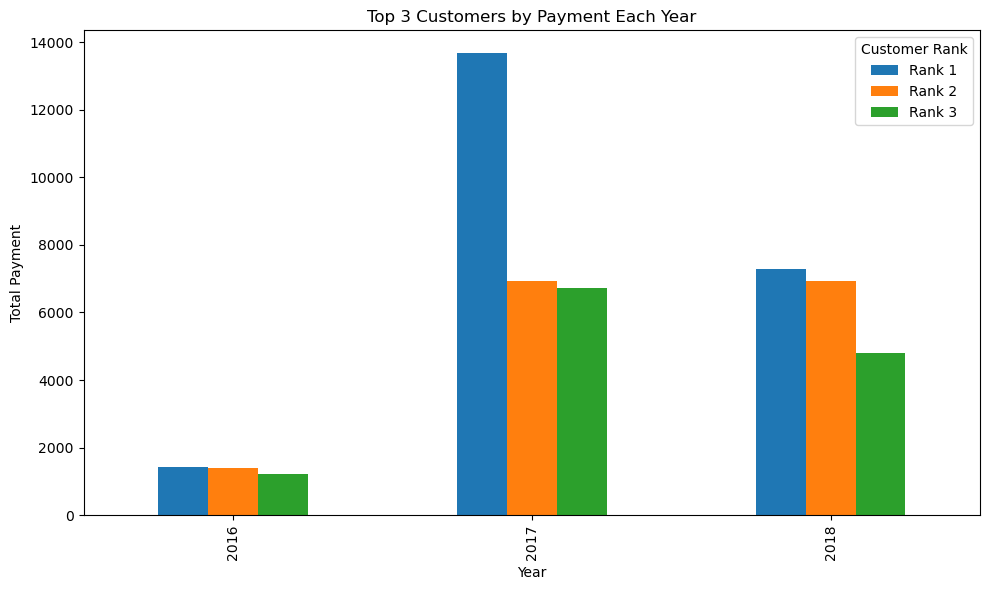

In [29]:
query="""select years,customer_id,payment,d_rank
        from
        (select year(orders.order_purchase_timestamp) years,
        orders.customer_id,sum(payments.payment_value) payment,
        dense_rank() over(partition by year(orders.order_purchase_timestamp)
        order by sum(payments.payment_value) desc) d_rank
        from orders join payments
        on payments.order_id=orders.order_id
        group by year(orders.order_purchase_timestamp),
        orders.customer_id) as a
        where d_rank <= 3"""
curr.execute(query)
data=curr.fetchall()

df = pd.DataFrame(data,columns=['year','customer_id','payment','rank'])

df['customer'] = df['customer_id'].str[:6]

pivot_df = df.pivot(index='year',
                    columns='rank',
                    values='payment')

pivot_df.columns = ['Rank 1','Rank 2','Rank 3']

pivot_df.plot(kind='bar', figsize=(10,6))

plt.title('Top 3 Customers by Payment Each Year')
plt.xlabel('Year')
plt.ylabel('Total Payment')
plt.legend(title='Customer Rank')
plt.tight_layout()
plt.show()